In [1]:
import sys

sys.path.append("..")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data_pipeline import build_air_quality_features

df_feat = build_air_quality_features(
    "../data/raw/city_day.csv", target_city="Delhi"
)
print("Engineered dataset shape:", df_feat.shape)
df_feat[
    ["Date", "PM2.5", "Target_PM25_t1", "Log_Target_PM25_t1"]
].head(3)

c:\Users\HP\Documents\P_jects\air_quality\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Engineered dataset shape: (1213, 42)


,Date,PM2.5,Target_PM25_t1,Log_Target_PM25_t1
0,2015-01-15,166.19,174.98,5.170370
1,2015-01-16,174.98,196.46,5.285536
2,2015-01-17,196.46,201.51,5.310789


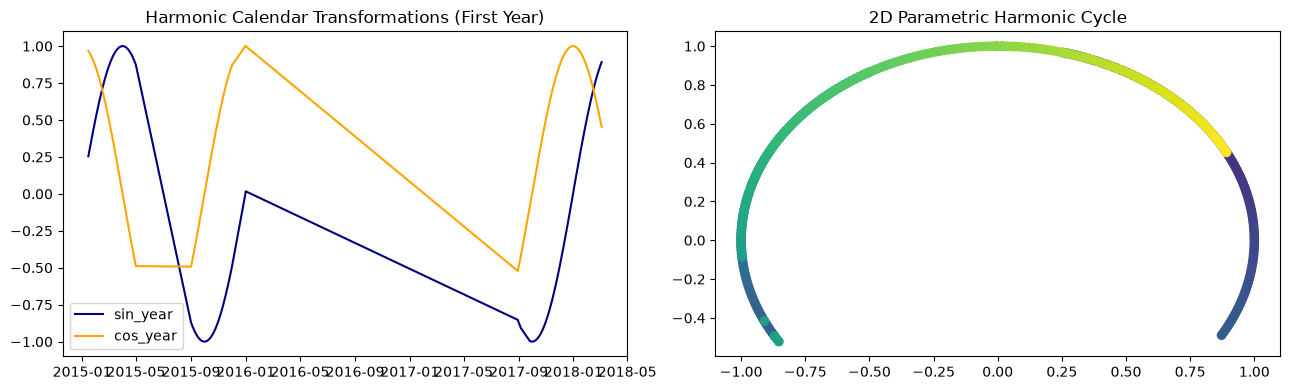

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(
    df_feat["Date"][:365],
    df_feat["sin_year"][:365],
    label="sin_year",
    color="navy",
)
axes[0].plot(
    df_feat["Date"][:365],
    df_feat["cos_year"][:365],
    label="cos_year",
    color="orange",
)
axes[0].set_title("Harmonic Calendar Transformations (First Year)")
axes[0].legend()

axes[1].scatter(
    df_feat["sin_year"][:365],
    df_feat["cos_year"][:365],
    c=df_feat.index[:365],
    cmap="viridis",
)
axes[1].set_title("2D Parametric Harmonic Cycle")
plt.tight_layout()
plt.show()

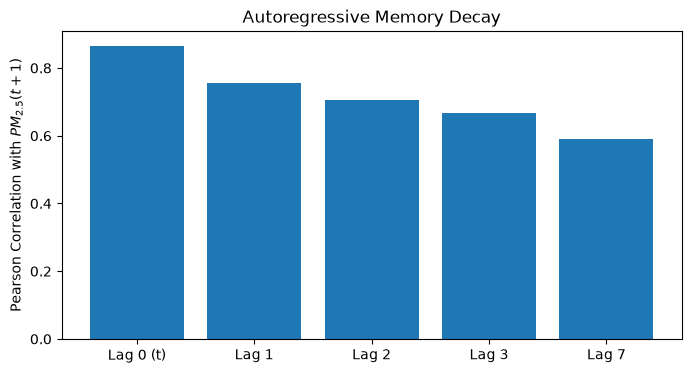

In [3]:
lags = ["PM2.5_lag1", "PM2.5_lag2", "PM2.5_lag3", "PM2.5_lag7"]
corr_vals = [
    df_feat["Target_PM25_t1"].corr(df_feat[col])
    for col in ["PM2.5"] + lags
]

plt.figure(figsize=(8, 4))
plt.bar(["Lag 0 (t)", "Lag 1", "Lag 2", "Lag 3", "Lag 7"], corr_vals, color="#1f77b4")
plt.ylabel("Pearson Correlation with $PM_{2.5}(t+1)$")
plt.title("Autoregressive Memory Decay")
plt.show()

In [4]:
df_feat.to_csv("../data/processed/delhi_featured.csv", index=False)
print("Successfully generated and saved ../data/processed/delhi_featured.csv")

Successfully generated and saved ../data/processed/delhi_featured.csv
